# Top

In [33]:
%matplotlib inline
import os
import json

# experiment_dir = "../stats/exp-2024-12-05_16-56-41"
experiment_dir = "../stats/exp-2024-12-09_09-35-32-snl"
json_files = [f for f in os.listdir(experiment_dir + "/json") if f.endswith(".json")]

experiment_data: list[dict] = []
for json_file in json_files:
    with open(os.path.join(experiment_dir + "/json/", json_file), "r") as f:
        data: dict = json.load(f)
        if "error" in data["verimon"]:
            print(f"Error in {json_file}: {data['verimon']['error']}")
            continue
        experiment_data.append(data)

print(f"Loaded {len(experiment_data)} JSON files from {experiment_dir}")
experiment_data.sort(
    key=lambda x: (x["experiment"]["name"], str(x["experiment"]["variant"]))
)
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment {longest_experiment['experiment']['name']} {longest_experiment['experiment']['variant']} took {longest_experiment['time']['total']:.2f} s ({longest_experiment['time']['total'] / (60 * 60):.2f} h)."
)

Loaded 8 JSON files from ../stats/exp-2024-12-09_09-35-32-snl
Longest experiment snakes_ladders [0, 6] took 1095.88 s (0.30 h).


In [34]:
import matplotlib.pyplot as plt

symbols = [
    "o",
    "s",
    "D",
    "^",
    "v",
    "<",
    ">",
    "p",
    "*",
    "h",
    "H",
    "+",
    "x",
    "d",
    "|",
    "_",
    ".",
    "1",
]
colors = plt.get_cmap("tab20")

experiment_names = set(data["experiment"]["name"] for data in experiment_data)
experiment_symbols = {
    name: symbols[i % len(symbols)] for i, name in enumerate(experiment_names)
}

for i, exp in enumerate(experiment_data):
    exp["symbol"] = experiment_symbols[exp["experiment"]["name"]]
    exp["color"] = colors(i % colors.N)

# Compare runtimes of verimon and traditional learning

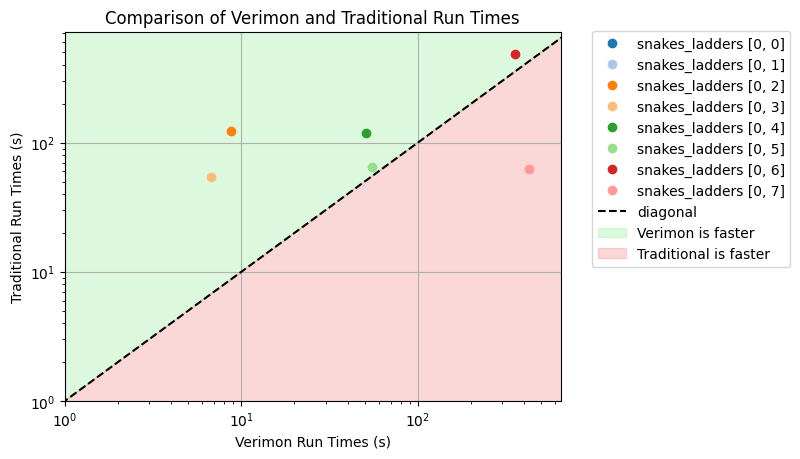

In [35]:
import matplotlib.pyplot as plt

max_verimon = 0
max_trad = 0
for i, data in enumerate(experiment_data):
    verimon_time = data["verimon"]["time"]
    trad_time = data["traditional"]["time"]
    if verimon_time is None or trad_time is None:
        continue
    max_verimon = max(max_verimon, verimon_time)
    max_trad = max(max_trad, trad_time)
    plt.plot(
        verimon_time,
        trad_time,
        data["symbol"],
        color=data["color"],
        label=f"{data['experiment']['name']} {data['experiment']['variant']}",
    )

plt.xlabel("Verimon Run Times (s)")
plt.ylabel("Traditional Run Times (s)")
plt.title("Comparison of Verimon and Traditional Run Times")
plt.plot(
    [0, max(max_verimon, max_trad) * 1.5],
    [0, max(max_verimon, max_trad) * 1.5],
    "k--",
    label="diagonal",
)
plt.fill_between(
    [0, max(max_verimon, max_trad) * 1.5],
    [0, max(max_verimon, max_trad) * 1.5],
    max(max_verimon, max_trad) * 1.5,
    color="lightgreen",
    alpha=0.3,
    label="Verimon is faster",
)
plt.fill_between(
    [0, max(max_verimon, max_trad) * 1.5],
    0,
    [0, max(max_verimon, max_trad) * 1.5],
    color="lightcoral",
    alpha=0.3,
    label="Traditional is faster",
)
plt.xlim(1, max_verimon * 1.5)
plt.ylim(1, max_trad * 1.5)
plt.grid()
plt.xscale("log")
plt.yscale("log")

plt.legend(bbox_to_anchor=(1.05, 1.02), loc="upper left")
plt.show()

# Compared learned thresholds of verimon and traditional learning

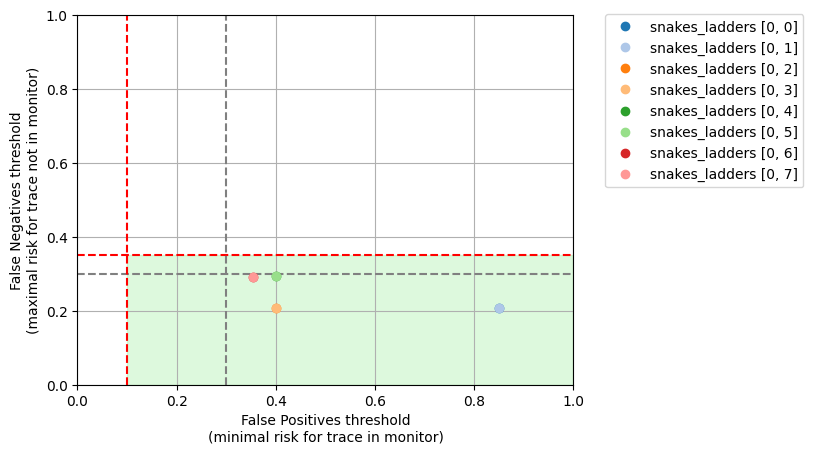

In [36]:
import matplotlib.pyplot as plt

plt.axhline(y=0.3, color="gray", linestyle="--")
plt.axhline(y=0.35, color="r", linestyle="--")
plt.axvline(x=0.3, color="gray", linestyle="--")
plt.axvline(x=0.1, color="r", linestyle="--")
plt.fill_betweenx([0, 0.35], 0.1, 1, color="lightgreen", alpha=0.3)

for i, data in enumerate(experiment_data):
    verimon_fp = data["verimon"]["false_positive"]
    verimon_fp = 0 if verimon_fp is None else verimon_fp
    verimon_fn = data["verimon"]["false_negative"]
    verimon_fn = 1 if verimon_fn is None else verimon_fn
    trad_fp = data["traditional"]["false_positive"]
    trad_fp = 0 if trad_fp is None else trad_fp
    trad_fn = data["traditional"]["false_negative"]
    trad_fn = 1 if trad_fn is None else trad_fn

    plt.plot(
        [verimon_fp],
        [verimon_fn],
        data["symbol"],
        color=data["color"],
        label=f"{data['experiment']['name']} {data['experiment']['variant']}",
    )
    plt.plot([verimon_fp, trad_fp], [verimon_fn, trad_fn], color=colors(i % colors.N))

plt.xlabel("False Positives threshold\n(minimal risk for trace in monitor)")
plt.ylabel("False Negatives threshold\n(maximal risk for trace not in monitor)")
plt.legend(bbox_to_anchor=(1.05, 1.02), loc="upper left")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()
plt.show()

# Compare learned monitor sizes

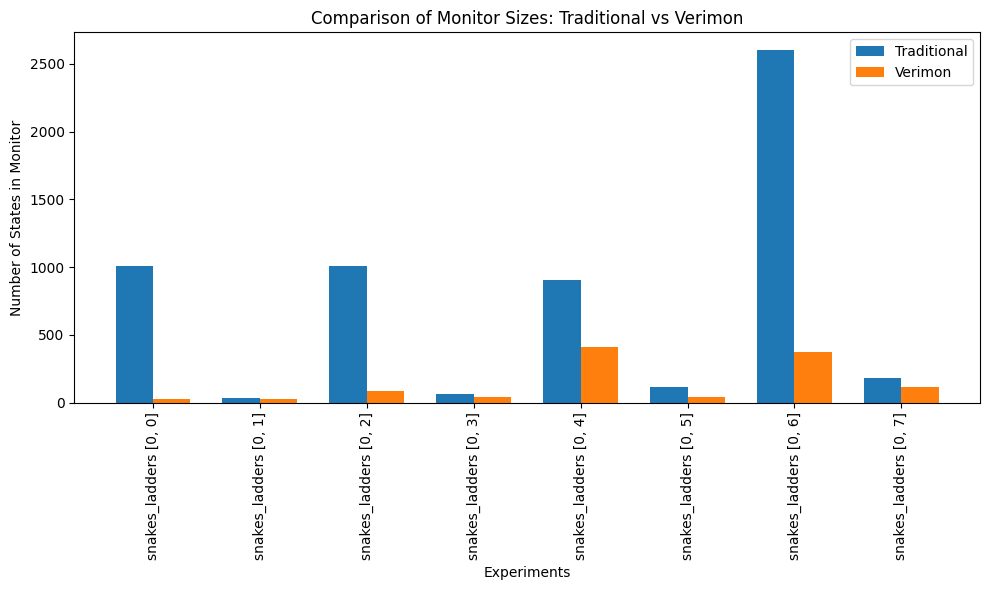

In [37]:
trad_monitor_sizes = [data["traditional"]["monitor_states"] for data in experiment_data]
verimon_monitor_sizes = [data["verimon"]["monitor_states"] for data in experiment_data]
experiment_names = [
    data["experiment"]["name"] + " " + str(data["experiment"]["variant"])
    for data in experiment_data
]

plt.figure(figsize=(10, 6))
bar_width = 0.35
index = range(len(experiment_data))

plt.bar(index, trad_monitor_sizes, bar_width, label="Traditional")
plt.bar(
    [i + bar_width for i in index], verimon_monitor_sizes, bar_width, label="Verimon"
)

plt.xlabel("Experiments")
plt.ylabel("Number of States in Monitor")
plt.title("Comparison of Monitor Sizes: Traditional vs Verimon")
plt.xticks([i + bar_width / 2 for i in index], experiment_names, rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

# Runtime by amount of mc states

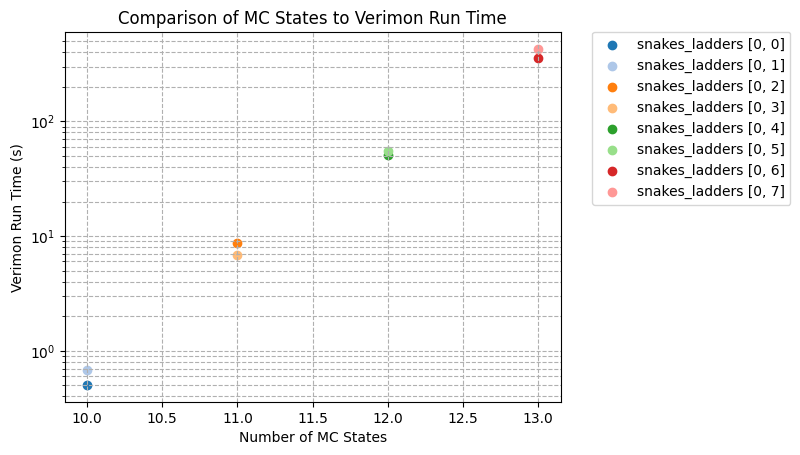

In [ ]:
for data in experiment_data:
    plt.scatter(
        data["experiment"]["horizon"],
        data["verimon"]["time"],
        marker=data["symbol"],
        color=data["color"],
        label=f"{data['experiment']['name']} {data['experiment']['variant']}",
    )

plt.legend(bbox_to_anchor=(1.05, 1.02), loc="upper left")

plt.xlabel("Horizon")
plt.ylabel("Verimon Run Time (s)")
plt.title("Comparison of MC States to Verimon Run Time")
# plt.xscale('log')
plt.yscale("log")
plt.grid(True, which="both", ls="--")
plt.show()

# Compare horizon on and off in snakes and ladders data

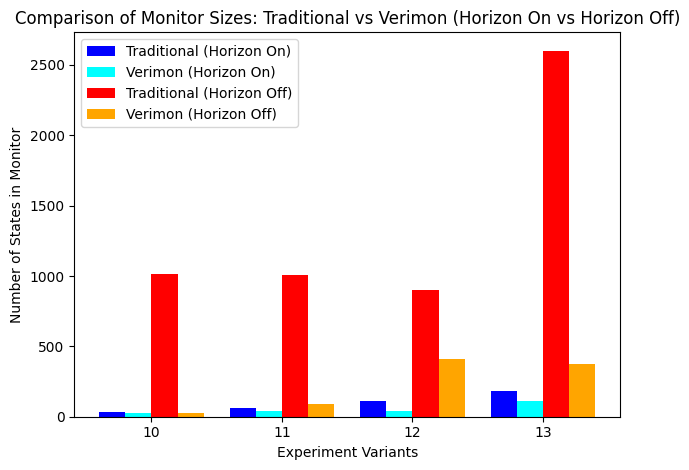

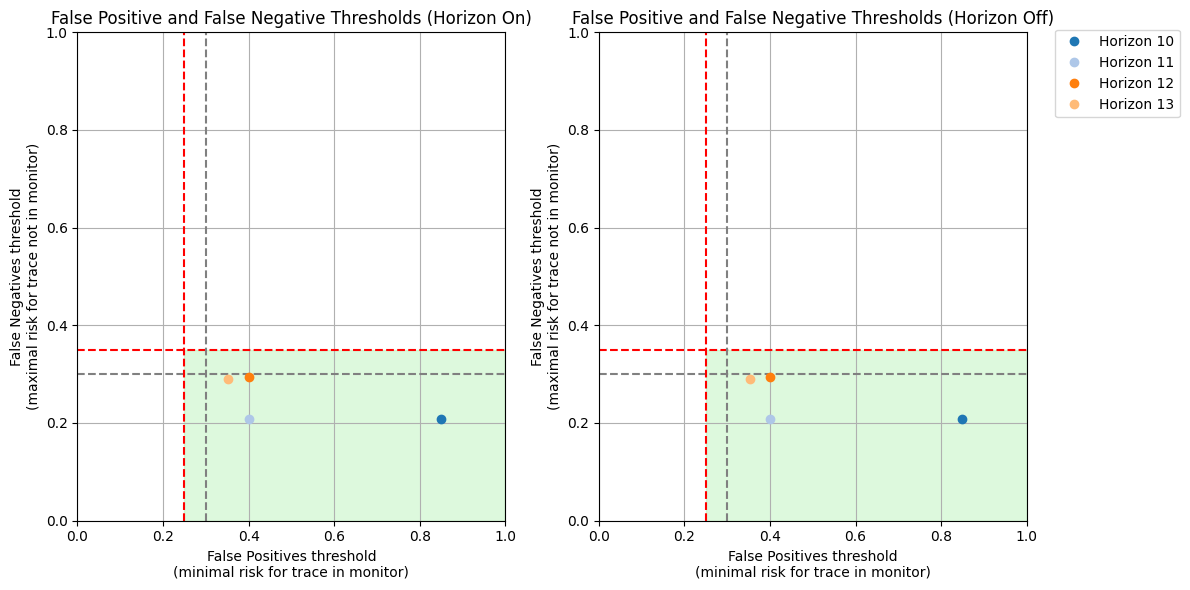

In [39]:
# Filter data for snakes and ladders experiments
snakes_ladders_data = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "snakes_ladders"
    ],
    key=lambda x: x["experiment"]["horizon"],
)

# Separate data based on use_horizon_in_filtering
horizon_on_data = [
    data
    for data in snakes_ladders_data
    if data["experiment"]["use_horizon_in_filtering"]
]
horizon_off_data = [
    data
    for data in snakes_ladders_data
    if not data["experiment"]["use_horizon_in_filtering"]
]

# Extract monitor sizes
horizon_on_trad_sizes = [
    data["traditional"]["monitor_states"] for data in horizon_on_data
]
horizon_on_verimon_sizes = [
    data["verimon"]["monitor_states"] for data in horizon_on_data
]
horizon_off_trad_sizes = [
    data["traditional"]["monitor_states"] for data in horizon_off_data
]
horizon_off_verimon_sizes = [
    data["verimon"]["monitor_states"] for data in horizon_off_data
]

# Horizon sizes for x-axis labels
horizon_on_names = [data["experiment"]["horizon"] for data in horizon_on_data]
horizon_off_names = [data["experiment"]["horizon"] for data in horizon_off_data]

bar_width = 1 / 4 - 0.05
index_on = range(len(horizon_on_data))
index_off = range(len(horizon_off_data))

# Plot for use_horizon_in_filtering = True
plt.bar(
    index_on,
    horizon_on_trad_sizes,
    bar_width,
    label="Traditional (Horizon On)",
    color="blue",
)
plt.bar(
    [i + bar_width for i in index_on],
    horizon_on_verimon_sizes,
    bar_width,
    label="Verimon (Horizon On)",
    color="cyan",
)

# Plot for use_horizon_in_filtering = False
plt.bar(
    [i + 2 * bar_width for i in index_off],
    horizon_off_trad_sizes,
    bar_width,
    label="Traditional (Horizon Off)",
    color="red",
)
plt.bar(
    [i + 3 * bar_width for i in index_off],
    horizon_off_verimon_sizes,
    bar_width,
    label="Verimon (Horizon Off)",
    color="orange",
)

plt.xlabel("Experiment Variants")
plt.ylabel("Number of States in Monitor")
plt.title(
    "Comparison of Monitor Sizes: Traditional vs Verimon (Horizon On vs Horizon Off)"
)
plt.xticks(
    [i + bar_width * 3 / 2 for i in index_on],
    horizon_on_names,
)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

# Plot for use_horizon_in_filtering = True
plt.subplot(1, 2, 1)
plt.axhline(y=0.3, color="gray", linestyle="--")
plt.axhline(y=0.35, color="r", linestyle="--")
plt.axvline(x=0.3, color="gray", linestyle="--")
plt.axvline(x=0.25, color="r", linestyle="--")
plt.fill_betweenx([0, 0.35], 0.25, 1, color="lightgreen", alpha=0.3)

for i, data in enumerate(horizon_on_data):
    verimon_fp = data["verimon"]["false_positive"]
    trad_fp = data["traditional"]["false_positive"]
    verimon_fn = data["verimon"]["false_negative"]
    trad_fn = data["traditional"]["false_negative"]

    plt.plot(
        [verimon_fp],
        [verimon_fn],
        data["symbol"],
        color=colors(data["experiment"]["horizon"] - 10 % colors.N),
        label=f"Horizon {data['experiment']['horizon']}",
    )
    plt.plot([verimon_fp, trad_fp], [verimon_fn, trad_fn], color=colors(i % colors.N))

plt.xlabel("False Positives threshold\n(minimal risk for trace in monitor)")
plt.ylabel("False Negatives threshold\n(maximal risk for trace not in monitor)")
plt.title("False Positive and False Negative Thresholds (Horizon On)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()

# Plot for use_horizon_in_filtering = False
plt.subplot(1, 2, 2)
plt.axhline(y=0.3, color="gray", linestyle="--")
plt.axhline(y=0.35, color="r", linestyle="--")
plt.axvline(x=0.3, color="gray", linestyle="--")
plt.axvline(x=0.25, color="r", linestyle="--")
plt.fill_betweenx([0, 0.35], 0.25, 1, color="lightgreen", alpha=0.3)

for i, data in enumerate(horizon_off_data):
    verimon_fp = data["verimon"]["false_positive"]
    trad_fp = data["traditional"]["false_positive"]
    verimon_fn = data["verimon"]["false_negative"]
    trad_fn = data["traditional"]["false_negative"]

    plt.plot(
        [verimon_fp],
        [verimon_fn],
        data["symbol"],
        color=colors(data["experiment"]["horizon"] - 10 % colors.N),
        label=f"Horizon {data['experiment']['horizon']}",
    )
    plt.plot([verimon_fp, trad_fp], [verimon_fn, trad_fn], color=colors(i % colors.N))


plt.xlabel("False Positives threshold\n(minimal risk for trace in monitor)")
plt.ylabel("False Negatives threshold\n(maximal risk for trace not in monitor)")
plt.title("False Positive and False Negative Thresholds (Horizon Off)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()

plt.legend(bbox_to_anchor=(1.05, 1.02), loc="upper left")
plt.tight_layout()
plt.show()

# Relative time spent in paynt, product generator and other

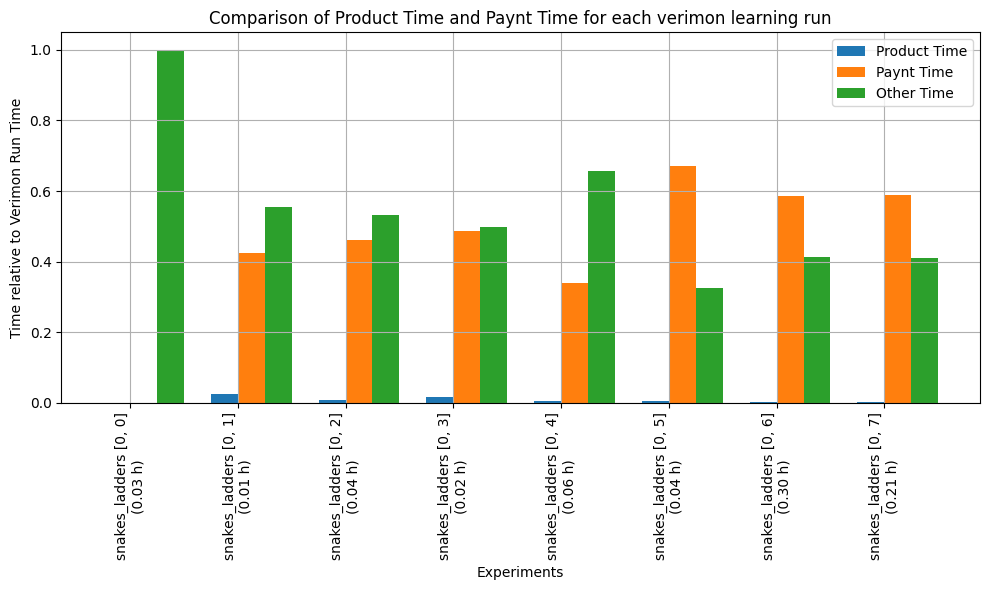

In [40]:
product_times = [
    (
        data["verimon"]["product_time"] / data["verimon"]["time"]
        if "product_time" in data["verimon"]
        else 0
    )
    for data in experiment_data
]
paynt_times = [
    (
        data["verimon"]["paynt_time"] / data["verimon"]["time"]
        if "product_time" in data["verimon"]
        else 0
    )
    for data in experiment_data
]
other_times = [
    (
        1
        - (data["verimon"]["product_time"] + data["verimon"]["paynt_time"])
        / data["verimon"]["time"]
        if "product_time" in data["verimon"]
        else 0
    )
    for data in experiment_data
]

experiment_names = [
    f"{data['experiment']['name']} {data['experiment']['variant']}\n({data['time']['total']/(60*60):.2f} h)"
    for data in experiment_data
]

plt.figure(figsize=(10, 6))
bar_width = 0.25
index = range(len(experiment_data))

plt.bar(index, product_times, bar_width, label="Product Time")
plt.bar([i + bar_width for i in index], paynt_times, bar_width, label="Paynt Time")
plt.bar([i + bar_width * 2 for i in index], other_times, bar_width, label="Other Time")

plt.xlabel("Experiments")
plt.ylabel("Time relative to Verimon Run Time")
plt.title("Comparison of Product Time and Paynt Time for each verimon learning run")
plt.xticks([i + bar_width / 2 for i in index], experiment_names, rotation=90)
plt.legend()

plt.tight_layout()
plt.grid()
plt.show()